In [36]:
import numpy as np
import seaborn as sns
import pandas as pd
import os

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error as rmse

In [37]:
by_day_data = '../data/schedule_data/processed_data/by_day_with_count'
by_day_data = by_day_data
dataframes = [pd.read_csv(os.path.join(by_day_data,x)) for x in os.listdir(by_day_data) if x[-4:] == '.csv']
daily_df = pd.concat(dataframes, ignore_index=True)
daily_df['date'] = daily_df['date'].apply(lambda x: pd.Timestamp(x))
daily_df = daily_df[daily_df['date'] < pd.Timestamp('2025-09-01')]

daily_df = daily_df.rename(columns={'delay time (5,19]':'dt_short', 'delay time (19,120]':'dt_long', 'EB/WB':'dir'})

In [38]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),Avg. spd (km/h),RT dist (km),Interruption
0,2025-01-01,E,Woodfield Rd,12,7,3,0,16.4,153.4,10.6,11.92,30.13,0
1,2025-01-01,E,Blackburn St,0,0,0,0,16.4,153.4,10.6,11.92,30.13,0
2,2025-01-01,W,High Park Loop,0,0,0,0,16.4,153.4,10.6,11.92,30.13,0
3,2025-01-01,E,Gerrard St East at Beaton Ave,14,10,4,0,16.4,153.4,10.6,11.92,30.13,0
4,2025-01-01,E,Roncesvalles Ave,1,1,2,0,16.4,153.4,10.6,11.92,30.13,0


In [39]:
daily_df[daily_df.stop == 'Main St'].stop.unique()

array(['Main St'], dtype=object)

In [40]:
daily_df.date = daily_df.date.apply(pd.Timestamp)

In [41]:
# I want to add daily weather data. 
weather=pd.read_csv('../data/raw_data/Weatherstats_data/weatherstats_toronto_daily.csv')
#drop columns that consist exclusively of NaNs
weather.dropna(axis=1, how='all', inplace=True)
#Convert date from string to datetime type
weather.date = weather.date.apply(pd.Timestamp)

#fill remainder of the NaNs with '0'
weather.fillna(0, inplace=True)

columns = weather.columns
#the following columns have a deterministic relationship with the temperature so we are dropping them
columns = [x for x in columns if 'degdays' not in x]

# Choosing avg stats vs max/min stats
columns = [x for x in columns if 'max' not in x and 'min' not in x]
# Removing 'hourly data'
columns = [x for x in columns if 'hourly' not in x]
# Picking one time format
columns = [x for x in columns if 'sunrise_f' != x and 'sunset_f' != x]
columns = [x for x in columns if 'unixtime' not in x]
# Picking station pressure vs sea pressure
columns = [x for x in columns if 'avg_pressure_sea' != x]


weather['sunrise_hhmm'] = weather['sunrise_hhmm'].apply(pd.Timedelta)
weather['sunset_hhmm'] = weather['sunset_hhmm'].apply(pd.Timedelta)

weather = weather[columns]

In [42]:
first_date = daily_df['date'].min()
last_date = daily_df['date'].max()
weather = weather[weather['date'].between(first_date,last_date)]
weather.head()

,date,avg_temperature,avg_relative_humidity,avg_dew_point,avg_wind_speed,wind_gust_dir_10s,avg_pressure_station,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
174,2025-08-31,16.39,57.5,9.1,8.5,0.0,100.36,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:40:00,0 days 19:55:00,13.25,2.0
175,2025-08-30,15.00,58.5,7.5,13.0,31.0,99.96,24100,2.0,0.0,0.0,0.0,0.0,0 days 06:39:00,0 days 19:57:00,13.30,3.5
176,2025-08-29,13.55,64.5,6.0,19.5,31.0,99.73,24100,1.7,0.0,0.0,0.0,0.0,0 days 06:38:00,0 days 19:59:00,13.35,4.0
177,2025-08-28,14.95,73.5,11.8,17.5,32.0,99.53,18500,2.2,5.4,5.4,0.0,0.0,0 days 06:36:00,0 days 20:00:00,13.40,4.0
178,2025-08-27,17.00,58.0,6.7,19.5,26.0,99.86,24100,2.1,0.0,0.0,0.0,0.0,0 days 06:35:00,0 days 20:02:00,13.45,3.0


In [43]:
daily_df = pd.merge(daily_df, weather, on='date')

In [44]:
daily_df.head()

,date,dir,stop,bunch,gap,dt_short,dt_long,No. of Veh,Run time (min),Term time (min),...,avg_visibility,avg_health_index,precipitation,rain,snow,snow_on_ground,sunrise_hhmm,sunset_hhmm,daylight,avg_cloud_cover_8
0,2025-01-01,E,Woodfield Rd,12,7,3,0,16.4,153.4,10.6,...,16900,1.6,0.7,0.7,0.0,0.0,0 days 07:51:00,0 days 16:51:00,9.0,7.0
1,2025-01-01,E,Blackburn St,0,0,0,0,16.4,153.4,10.6,...,16900,1.6,0.7,0.7,0.0,0.0,0 days 07:51:00,0 days 16:51:00,9.0,7.0
2,2025-01-01,W,High Park Loop,0,0,0,0,16.4,153.4,10.6,...,16900,1.6,0.7,0.7,0.0,0.0,0 days 07:51:00,0 days 16:51:00,9.0,7.0
3,2025-01-01,E,Gerrard St East at Beaton Ave,14,10,4,0,16.4,153.4,10.6,...,16900,1.6,0.7,0.7,0.0,0.0,0 days 07:51:00,0 days 16:51:00,9.0,7.0
4,2025-01-01,E,Roncesvalles Ave,1,1,2,0,16.4,153.4,10.6,...,16900,1.6,0.7,0.7,0.0,0.0,0 days 07:51:00,0 days 16:51:00,9.0,7.0


In [45]:
# Fill na values with 0
daily_df.fillna(0, inplace=True)

In [46]:
features = ['dir', 'bunch', 'gap', 'Interruption']+weather.columns.to_list()
targets = [x for x in daily_df.columns if 'dt_' in x]

In [47]:
corr_matrix = daily_df[features+targets].select_dtypes(np.number).corr()

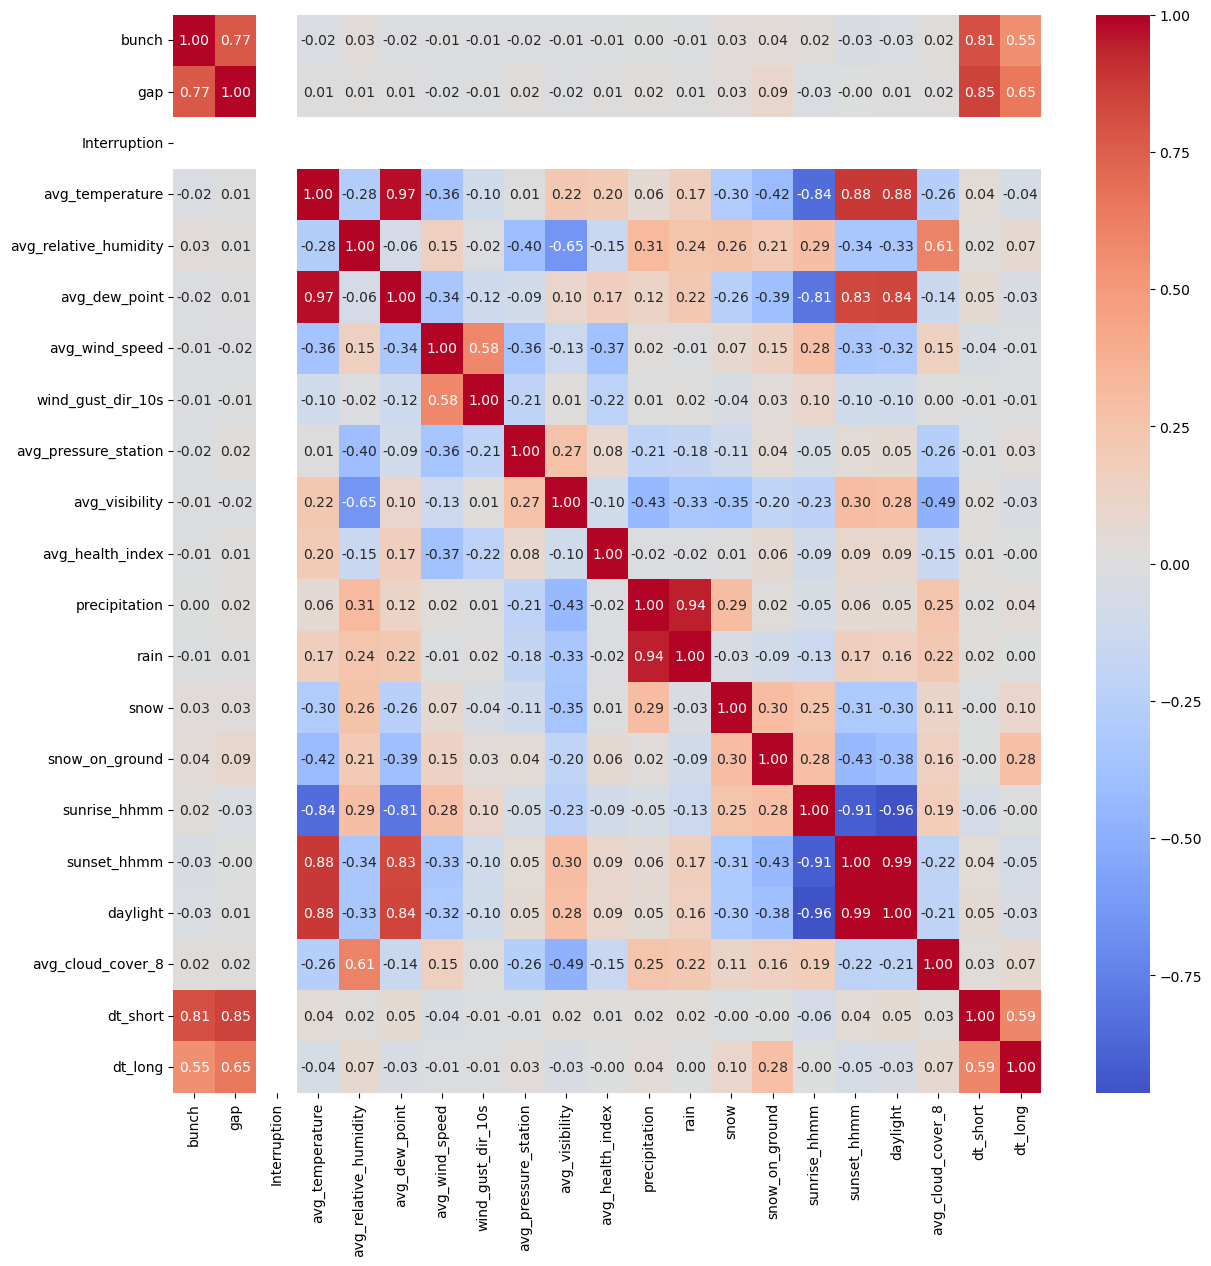

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,14))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0,
            fmt='.2f')
plt.show()

Most of these columns are either essentially repeats of other columns, or totally uncorrelated, except for the following features:
- Bunch, Gap, Interruption, avg_temperature, avg_wind_speed, avg_visibility, avg_health_index, rain, snow_on_ground, daylight

Interestingly, factors like windspeed seem to not play any role on the data.

Lets build a model around these features. First let's see a truncated version of the correlation matrix with only these features.

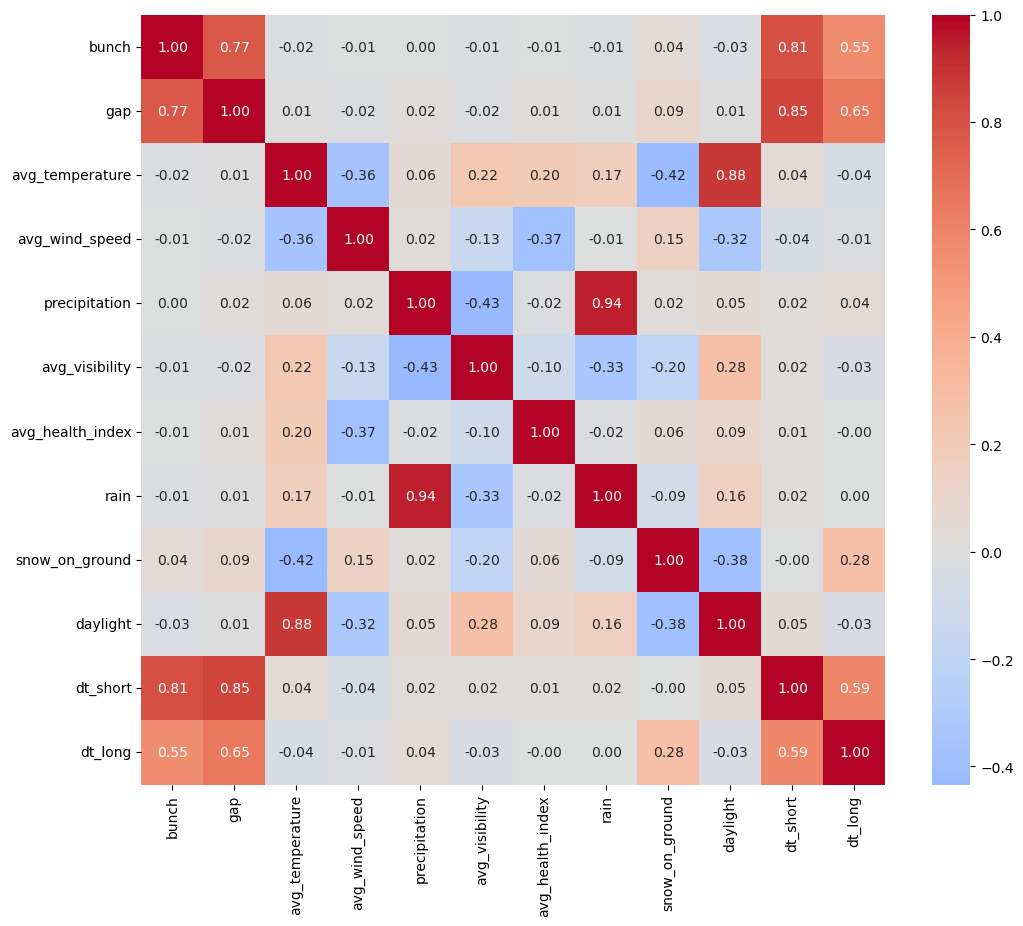

In [49]:
features = ['bunch', 'gap','avg_temperature', 'avg_wind_speed', 'precipitation', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight']
targets = [x for x in daily_df.columns if 'dt_' in x]

corr_matrix = daily_df[features+targets].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f');

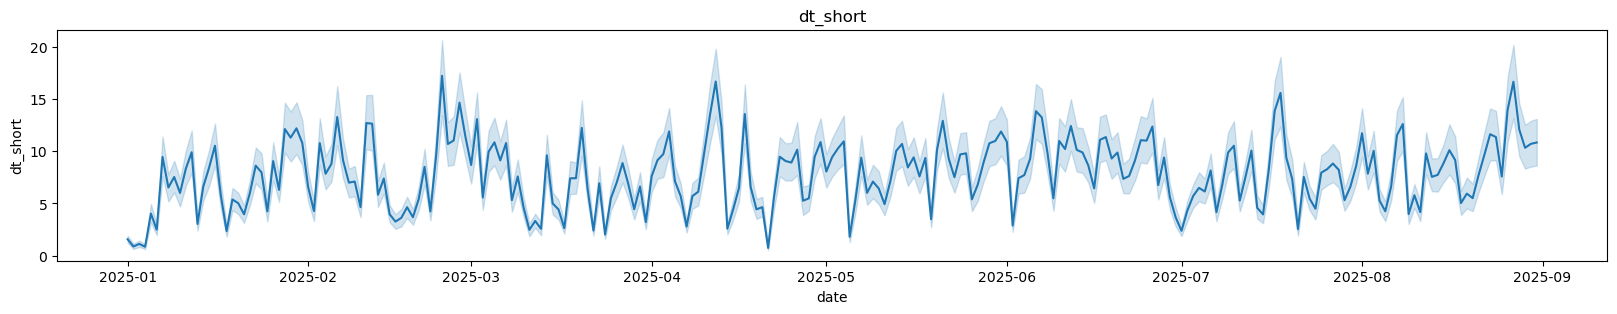

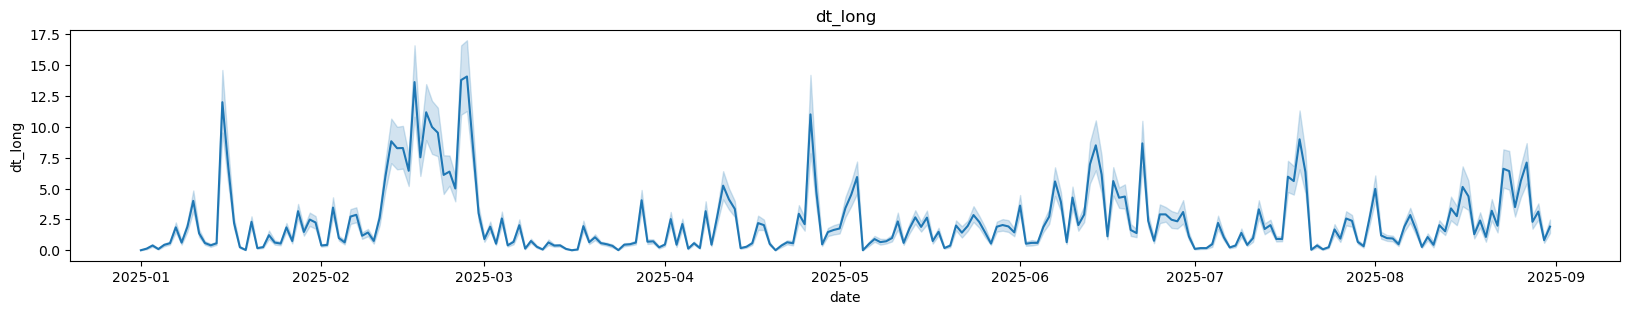

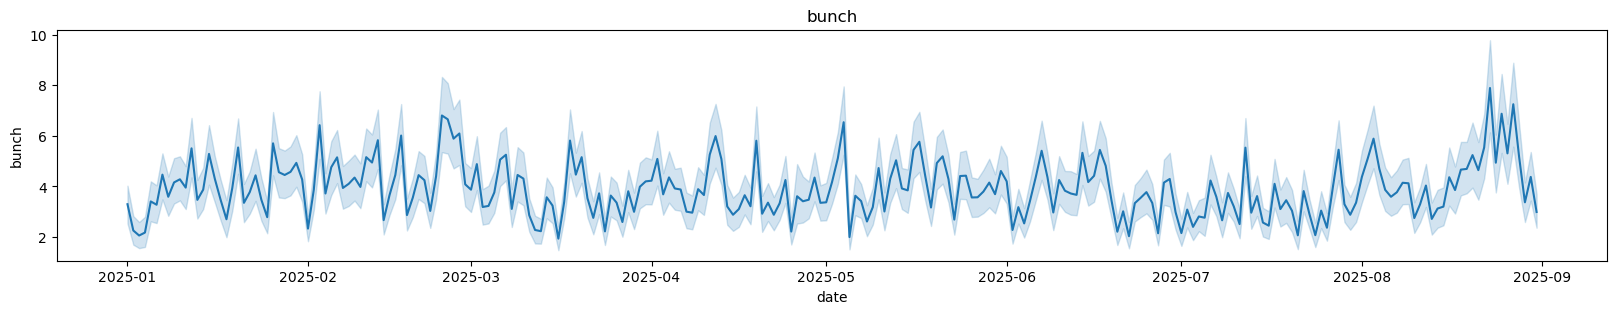

In [232]:
for dt in ['dt_short', 'dt_long']:
    plt.figure(figsize=(20,3))
    sns.lineplot(data=daily_df, x='date', y=dt)
    plt.title(dt)
    plt.show()

plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='bunch')
plt.title('bunch')
plt.show()

Some of the feature of the long term weight can be explained by snowfall.

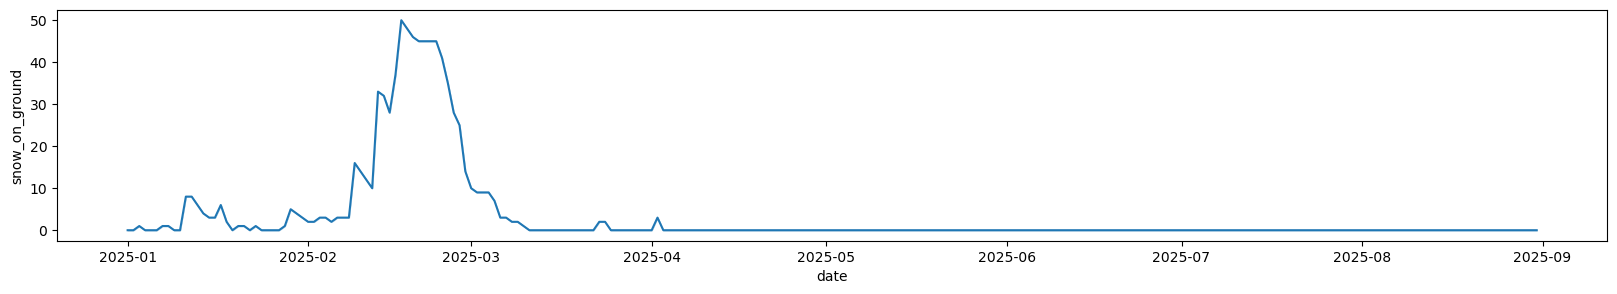

In [211]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='snow_on_ground')
plt.show()

Another region of 'spikes' corresponds to some of the hottest days of the year.

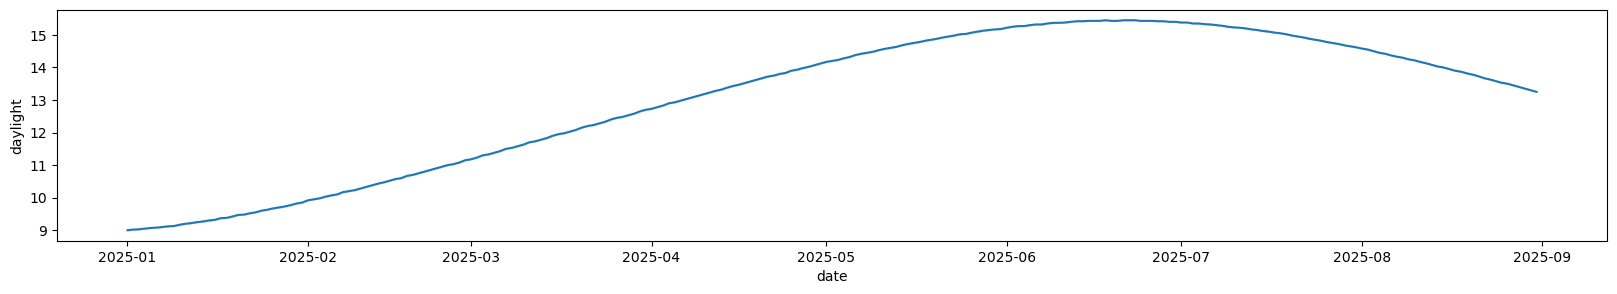

In [213]:
plt.figure(figsize=(20,3))
sns.lineplot(data=daily_df, x='date', y='daylight')
plt.show()

The ACF and PACF plots show no strong correlation between bunch events per day.

In [51]:
def count_feature(date, feature, df):
    if len(df[df['date'] == date][feature].tolist())==0:
        return 0
    else:
        return sum(df[df['date'] == date][feature])

bunch_events = []
start_date = daily_df.date.min()
end_date = daily_df.date.max()
timedelta = (end_date - start_date).days
for delta in range(timedelta):
    bunch_events.append(count_feature(start_date+pd.Timedelta(days=delta), 'bunch', daily_df))

bunch_events = np.array(bunch_events)

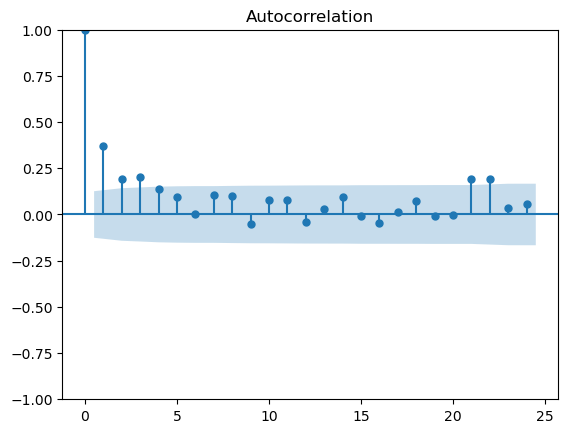

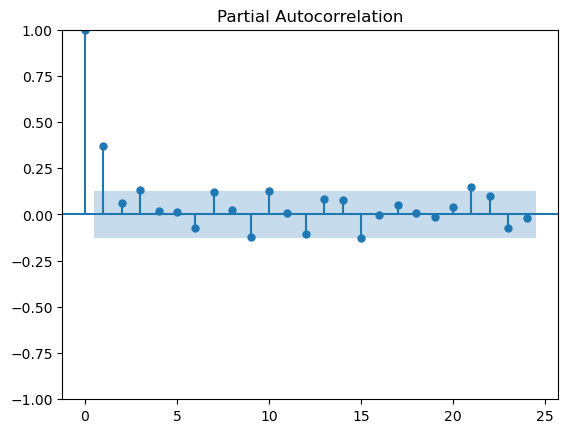

In [52]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
plot_acf(bunch_events)
plt.show()
plot_pacf(bunch_events)
plt.show()

We use xgboost since it's a very flexible model that generalizes well. According to (https://stats.stackexchange.com/questions/338904/measures-of-ordinal-classification-error-for-ordinal-regression)[this post on Cross Validated], RMSE is the best measure of performance for ordinal classification when the classes are reasonably balanced, and MAE should not be used. Note that 'dt_long' is *not* balanced, and so we will have to come to an analysis of this with a different metric.

In [56]:
# Let's try xgboost since it is a very flexible model
import xgboost as xgb
# First turn stop into a categorical feature.
daily_df['stop']=daily_df['stop'].astype('category')
daily_df['dir']=daily_df['dir'].astype('category')

loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_alpha=2,
                                reg_lambda=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

dt_short rmse mean: 4.208203411102295
dt_short rmse std: 1.6497594241518674
dt_short average R^2 score: 0.8898298144340515
dt_short R^2 score std: 0.09350544237250284

dt_long rmse mean: 2.407963824272156
dt_long rmse std: 0.6703722825969604
dt_long average R^2 score: 0.31648370027542116
dt_long R^2 score std: 0.4814686746721854



We're going to try to use Shapley values to do some analysis on the feature set, mimicking [Wendy's analysis on the effect of gender on pay](https://www.kaggle.com/code/manwaicheung/gender-pay-gap). One factor that we want to isolate is the direction of the streetcar.

In [57]:
import shap
shap.initjs()

In [58]:
df_filter = dict()
y_filter = dict()
X_filter= dict()
for target in ['dt_short', 'dt_long']:
    for dir in daily_df.dir.unique():
        df_filter[str(dir), target] = daily_df[(daily_df['dir']==dir)]
        X_filter[str(dir), target] = df_filter[str(dir), target][[x for x in features]]
        y_filter[str(dir), target] = df_filter[str(dir), target][target]


In [59]:
model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=200,
    learning_rate=0.1,
    enable_categorical=True,
    max_depth=10,
    reg_alpha=2,
    reg_lambda=0,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])

In [60]:
explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

Lets first see a waterfall plot to see how our function compares to the baseline

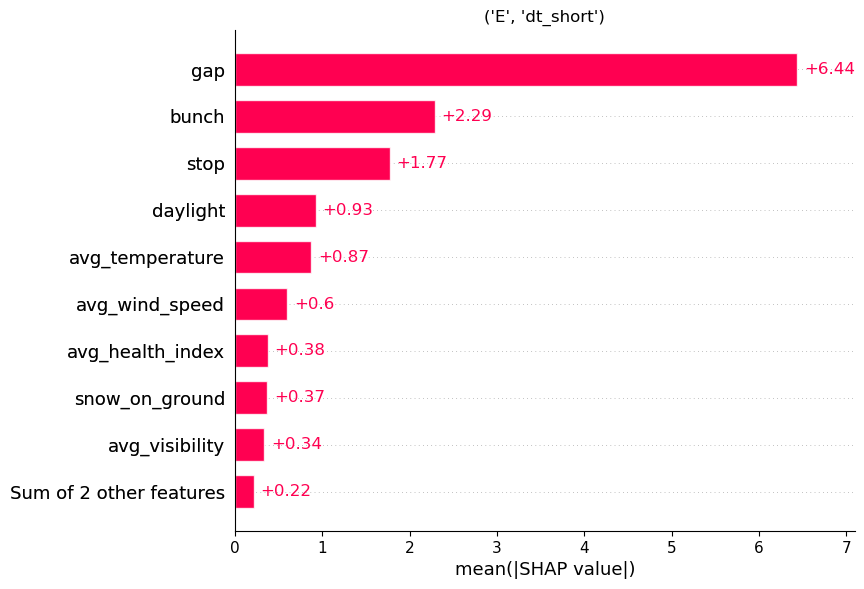

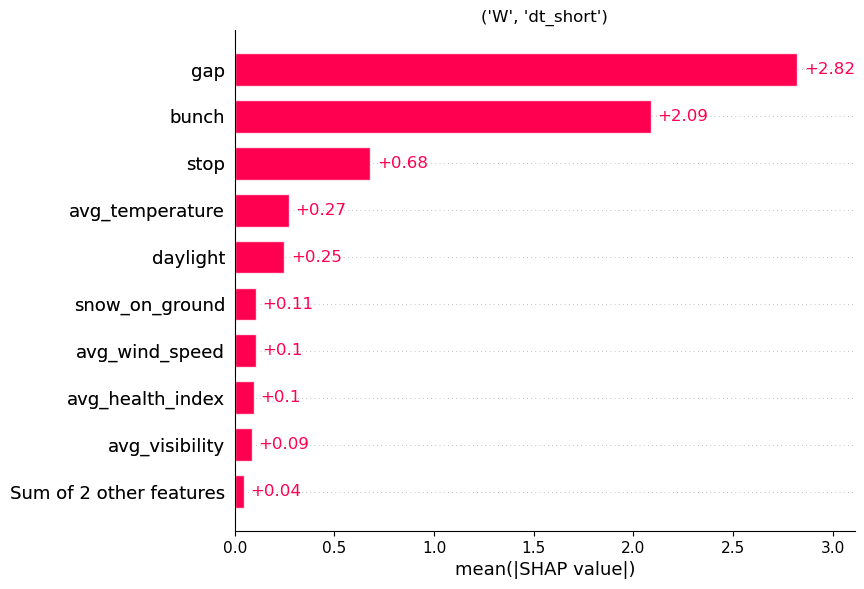

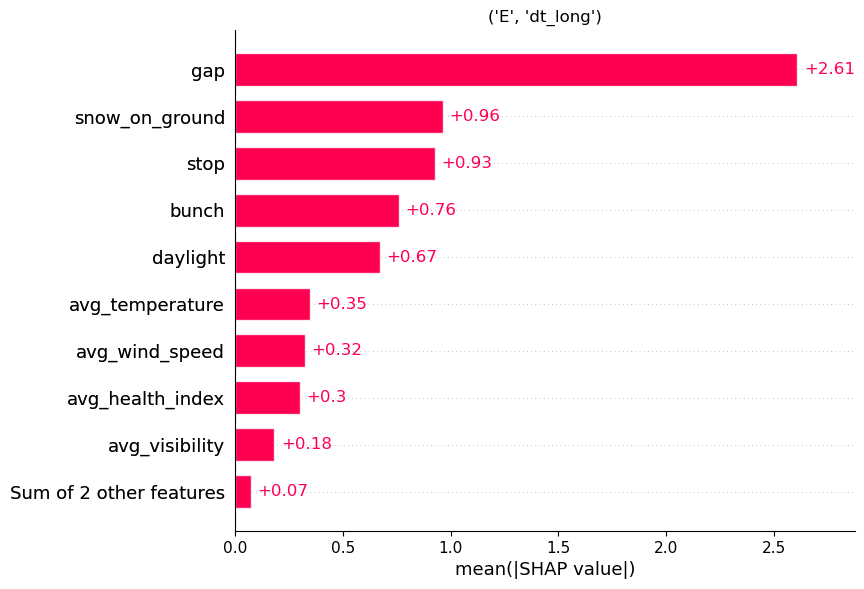

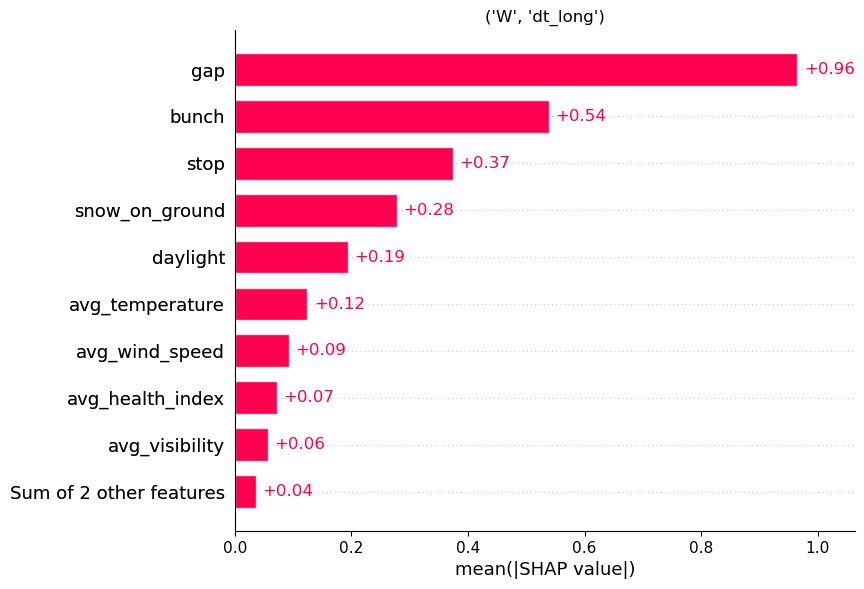

In [61]:
for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

That gap seems to be so dominant is very suspicious, especially since gapping events are defined as gaps between streetcars that are at least 19 minutes long. Therefore, we rerun the model without it.

In [208]:
loss = dict()
R2_score = dict()
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['dt_short', 'dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=200,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_lambda=2,
                                reg_alpha=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)
for dt in ['dt_short', 'dt_long']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

print(R2_score)

dt_short rmse mean: 3.302093267440796
dt_short rmse std: 0.8985309575776563
dt_short average R^2 score: 0.9374592661857605
dt_short R^2 score std: 0.03615963235395238

dt_long rmse mean: 1.8391153812408447
dt_long rmse std: 0.5302963191142316
dt_long average R^2 score: 0.5443824529647827
dt_long R^2 score std: 0.4357203707167961

{('dt_short', 0): 0.8709499835968018, ('dt_short', 1): 0.9564191102981567, ('dt_short', 2): 0.9317482113838196, ('dt_short', 3): 0.9517672061920166, ('dt_short', 4): 0.9764118194580078, ('dt_long', 0): 0.6846076250076294, ('dt_long', 1): -0.3147411346435547, ('dt_long', 2): 0.7829882502555847, ('dt_long', 3): 0.6864687204360962, ('dt_long', 4): 0.882588803768158}


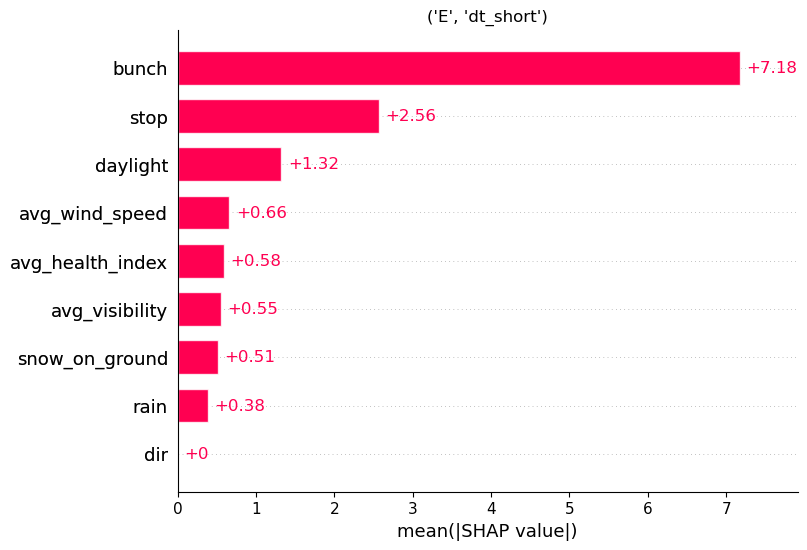

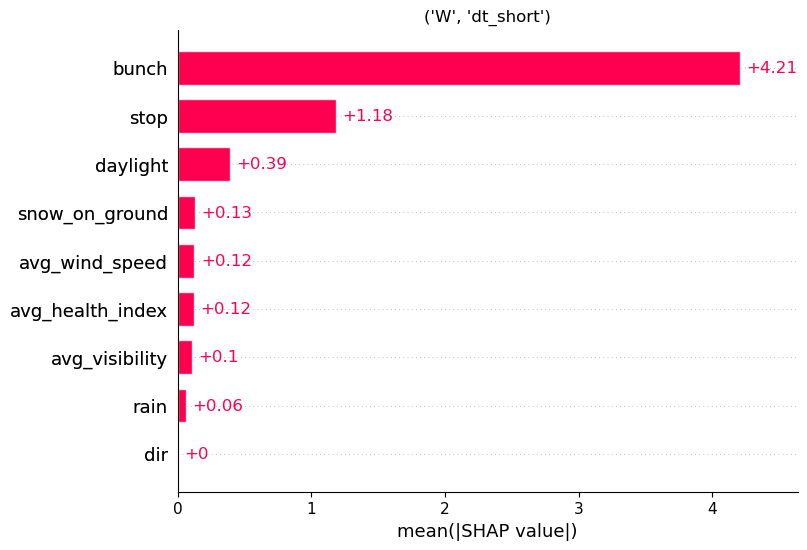

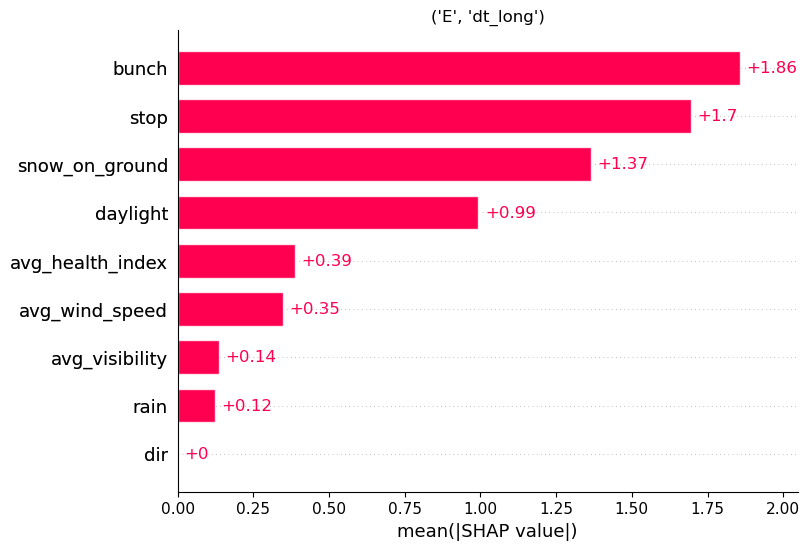

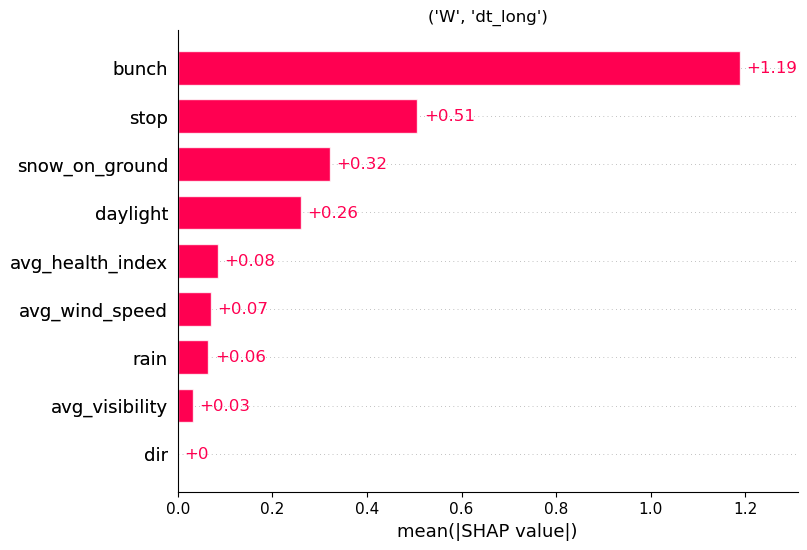

In [63]:
df_filter = dict()
y_filter = dict()
X_filter= dict()
for target in ['dt_short', 'dt_long']:
    for dir in daily_df.dir.unique():
        df_filter[str(dir), target] = daily_df[(daily_df['dir']==dir)]
        X_filter[str(dir), target] = df_filter[str(dir), target][[x for x in features]]
        y_filter[str(dir), target] = df_filter[str(dir), target][target]

model_filter = dict()
for key in df_filter.keys():
    model_filter[key] = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100,
    learning_rate=0.1,
    enable_categorical=True,
    max_depth=5,
    reg_lambda=4,
    reg_alpha=0,
    seed=37)
    model_filter[key].fit(X_filter[key], y_filter[key])

explainer_filter = dict()
shap_filter = dict()
for key in df_filter.keys():
    explainer_filter[key] = shap.Explainer(model_filter[key])
    shap_filter[key] = explainer_filter[key](X_filter[key])

for key in df_filter.keys():
    shap.plots.bar(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

Finally, we can look at the distribution of the features.

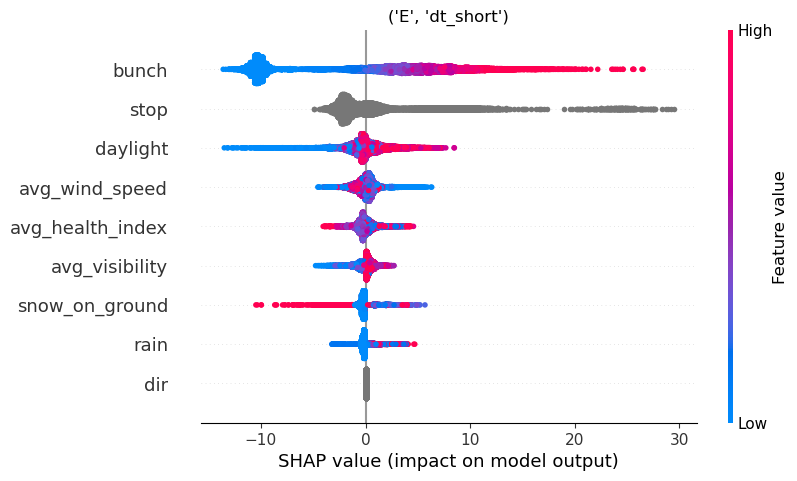

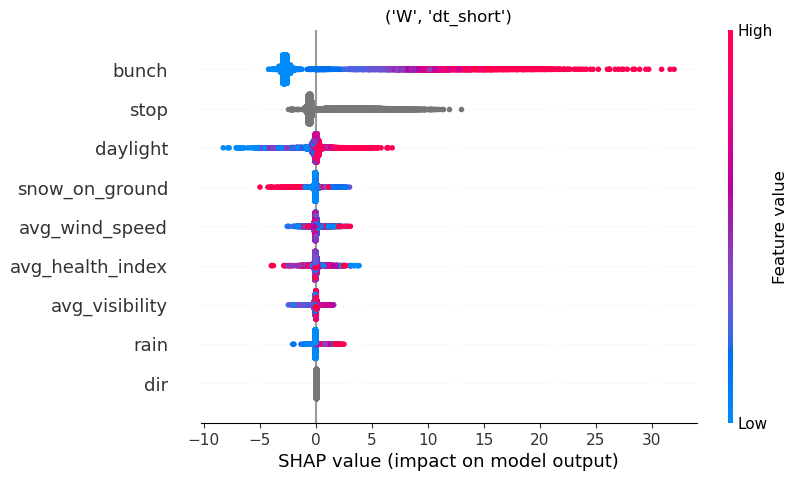

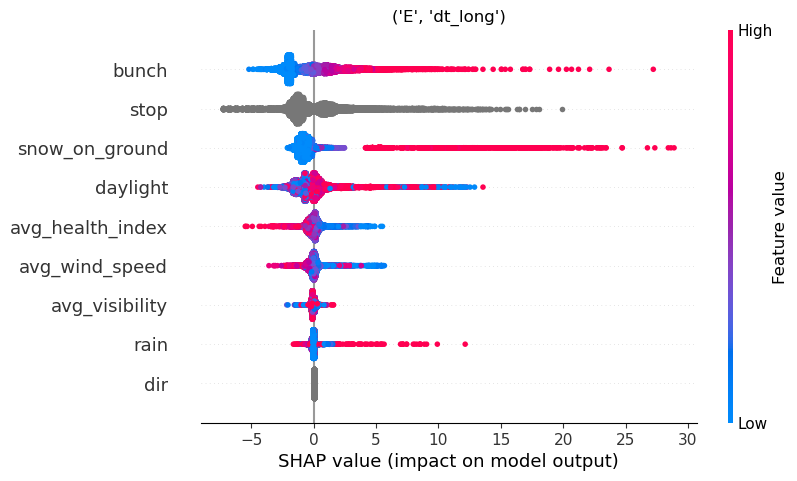

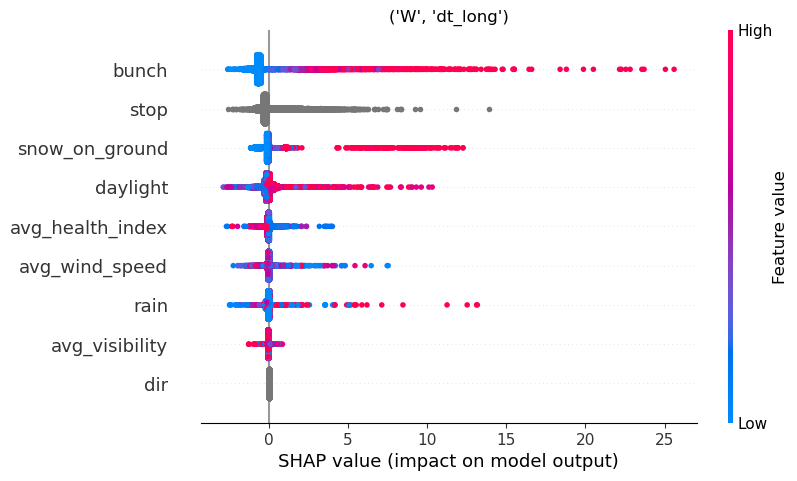

In [64]:
for key in df_filter.keys():
    shap.plots.beeswarm(shap_filter[key], show=False)
    plt.title(str(key))
    plt.show()

In fact, the short term delay time is also a strong predictor for the amount of gap events, suggesting that gap does not make a good feature for prediction.

In [219]:
loss = dict()
R2_score = dict()
features = ['dt_short', 'dir', 'stop']

tss = TimeSeriesSplit(n_splits=5, test_size=30)
for target in ['bunch','gap']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        model = xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=100,
                                enable_categorical=True,
                                learning_rate=0.1,
                                max_depth=10,
                                reg_lambda=5,
                                reg_alpha=0,
                                seed=37)

        X_train = df_train[features]
        y_train = df_train[target]
        X_test = df_test[features]
        y_test = df_test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        R2_score[target,idx] = r2_score(y_test, y_pred)
        loss[target,idx] = rmse(y_test, y_pred)

for dt in ['bunch','gap']:
    print(f'{dt} rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')

print(R2_score)

bunch rmse mean: 3.1475979328155517
bunch rmse std: 0.6090837040531157
bunch average R^2 score: 0.3653650045394897
bunch R^2 score std: 0.26580006763284136

gap rmse mean: 2.1927427768707277
gap rmse std: 0.5539353957919335
gap average R^2 score: 0.9024538278579712
gap R^2 score std: 0.05859134298691591

{('bunch', 0): 0.6460256576538086, ('bunch', 1): 0.43618297576904297, ('bunch', 2): 0.6005135774612427, ('bunch', 3): -0.07303857803344727, ('bunch', 4): 0.21714138984680176, ('gap', 0): 0.8135287761688232, ('gap', 1): 0.9413909912109375, ('gap', 2): 0.9518839716911316, ('gap', 3): 0.8512668609619141, ('gap', 4): 0.9541985392570496}


Finally, we come to an analysis of 'dt_long'. For this, we refer to the Cross Validated post again, and construct a custom objective. The sugested solution to dealing with class imbalances is to reweight them by frequency. Set $n$ to be the length of our test set and given an index $i < n$, let's set $w_i = |\{j < n: y_{\text{test},j} = y_{\text{test},i}\}|^{-1}$. The macro averaged mean squared error is given by the formula
$$
    \text{macro\_averaged\_mse}(y_\text{test}, y_{\text{pred}}) = \frac{1}{n} \sum_{i < n} w_i|y_{\text{test},i} - y_{\text{pred},i}|^2 \;.
$$

XGBoost needs a gradient and hessian of the loss function with respect to $y_{\text{pred}}$. The gradient of this loss function is given by
$$
    \frac{\partial}{\partial y_{\text{pred}}}\text{macro\_averaged\_mse}(y_\text{test}, y_{\text{pred}}) = \frac{2}{n} [w_i\cdot(y_{\text{test},i}-y_{\text{pred},i}) : i < n]
$$
and the hessian is
$$
    \frac{\partial^2}{\partial y_{\text{pred}}^T \partial y_{\text{pred}}}\text{mcaro\_averaged\_mse}(y_\text{test}, y_{\text{pred}}) = -\frac{2}{n}diag(w_i : i < n)
$$
Like the example in the XGBoost doc, it looks like we can drop constant terms in both the gradient and hessian.

We implement this below:

In [235]:
def macro_averaged_mse(y_true, dtrain):
    n= len(y_true)
    y_true = np.asarray(y_true)
    y_pred = dtrain.get_label()
    w = dict()
    for i in range(n):
        if y_true[i] in w.keys():
            w[y_true[i]] += 1
        else:
            w[y_true[i]] = 1


    weight = np.array([1/w[y_true[i]] for i in range(n)])


    hess = 2*weight
    grad = -2*weight*(y_true-y_pred)
    return grad, hess

def metric(y_true, dtrain):
    n= len(y_true)
    y_true = np.asarray(y_true)
    y_pred = dtrain.get_label()
    w = dict()
    for i in range(n):
        if y_true[i] in w.keys():
            w[y_true[i]] += 1
        else:
            w[y_true[i]] = 1

    root_weight = np.array([1/np.sqrt(w[y_true[i]]) for i in range(n)])

    return np.linalg.norm(root_weight*(y_true - y_pred))/n


def macro_averaged_rmse(y_true, y_pred):
    n= len(y_true)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    w = dict()
    for i in range(n):
        if y_true[i] in w.keys():
            w[y_true[i]] += 1
        else:
            w[y_true[i]] = 1

    root_weight = np.array([1/np.sqrt(w[y_true[i]]) for i in range(n)])
    return np.linalg.norm(root_weight*(y_true - y_pred))/n

In [236]:
loss = dict()
R2_score = dict()
features = ['bunch', 'gap', 'avg_temperature', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir','stop'
            ]

tss = TimeSeriesSplit(n_splits=5, test_size=30)

params = {
    'max_depth': 10,
    'learning_rate': 0.1,
    'disable_default_eval_metric': 1,
    'reg_alpha': 4,
    'seed': 37
}


for dt in ['dt_short','dt_long']:
    for idx, (tss_train, tss_test) in enumerate(tss.split(daily_df, daily_df.date)):
        df_train = daily_df.iloc[tss_train]
        df_test = daily_df.iloc[tss_test]

        X_train = df_train[features+[dt]]
        y_train = df_train[dt]
        dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)

        X_test = df_test[features+[dt]]
        y_test = df_test[dt]
        dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)


        model = xgb.train(params, dtrain, obj=macro_averaged_mse, custom_metric=metric, num_boost_round=100)
        y_pred = model.predict(dtest)

        R2_score[dt,idx] = r2_score(y_test, y_pred)
        loss[dt,idx] = macro_averaged_rmse(y_test, y_pred)

for dt in ['dt_short','dt_long']:
    print(f'{dt} macro averaged rmse mean: {np.array([val for key,val in loss.items() if key[0] == dt]).mean()}')
    print(f'{dt} macro averaged rmse std: {np.array([val for key,val in loss.items() if key[0] == dt]).std()}')
    print(f'{dt} average R^2 score: {np.array([val for key,val in R2_score.items() if key[0] == dt]).mean()}')
    print(f'{dt} R^2 score std: {np.array([val for key,val in R2_score.items() if key[0] == dt]).std()}\n')


dt_short macro averaged rmse mean: 390.7313871413095
dt_short macro averaged rmse std: 35.915084778264884
dt_short average R^2 score: -60633.0984375
dt_short R^2 score std: 2886.001269943793

dt_long macro averaged rmse mean: 0.5718689321230477
dt_long macro averaged rmse std: 0.20444866789925115
dt_long average R^2 score: -0.2241612195968628
dt_long R^2 score std: 0.11279740037334615



In [222]:
features = ['bunch', 'avg_wind_speed', 'avg_visibility', 'avg_health_index', 'rain', 'snow_on_ground', 'daylight', 'dir', 'stop']
tss = TimeSeriesSplit(n_splits=4, test_size=60)
tss_split = tss.split(daily_df, daily_df.date)
next(tss_split)
tss_train, tss_test = next(tss_split)

df_train = daily_df.iloc[tss_train]
df_test = daily_df.iloc[tss_test]

dt = 'dt_long'

model = xgb.XGBRegressor(objective='reg:squarederror',
                        n_estimators=200,
                        enable_categorical=True,
                        learning_rate=0.1,
                        max_depth=10,
                        reg_alpha=2,
                        reg_lambda=0,
                        seed=37)

X_train = df_train[features]
y_train = df_train[dt]


X_test = df_test[features]
y_test = df_test[dt]


model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)

df_pred = df_test.copy()
df_pred[dt] = y_pred


df_pred_train = df_train.copy()
df_pred_train[dt] = y_pred_train

<Axes: ylabel='dt_long'>

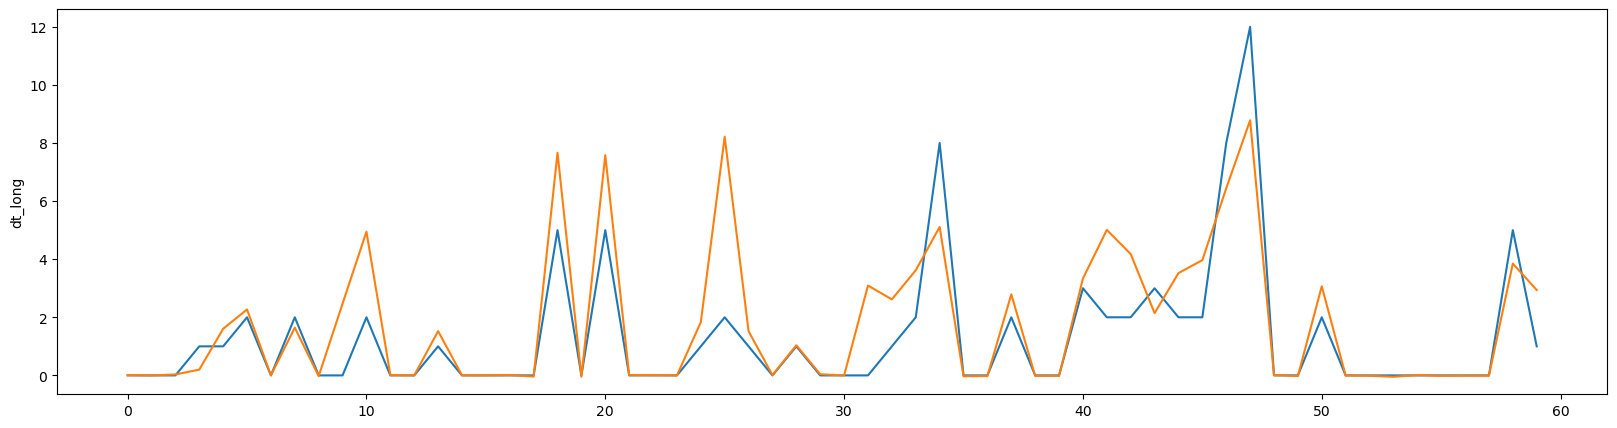

In [223]:
plt.figure(figsize=(20,5))
#sns.lineplot(df_train, x='date', y='dt_long')
sns.lineplot(x=range(60), y=y_test)
sns.lineplot(x=range(60), y=y_pred)